In [1]:
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.types import Command
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from typing_extensions import Literal
from IPython.display import Image, display

In [26]:
# Define State

class SupervisorAgentState(MessagesState):
    """ Superviosr Multi-Agent """
    next_agent: str = ""
    pre_check: str = ""
    contract: str = ""
    summarize: str = ""
    post_check: str = ""
    is_task_complete: bool = False

In [15]:
def pre_check_agent(state: SupervisorAgentState) -> SupervisorAgentState:
    """Checing all input before passing to Supervisor"""

    print("<- pre_check_agent ->")
    sys_msg= SystemMessage(content="Your are a smart assistant. your task is to validate all parameters recveid from user's input before passing to Supervisor")
    
    state["messages"].append(sys_msg)
    state["next_agent"]= "Contract"
    state["is_task_complete"]= False
    
    print("Pre_check Validation is Successfully completed and share result with 'Supervisor Agent'")
    
    return state 

In [30]:
def supervisor(state: SupervisorAgentState) -> Command[Literal["Contract", "Summarize", "Post_Check"]]:
    """Supervisor is responsible to assiging task to member's"""

    print("\n<- supervisor ->")
    
    sys_msg= SystemMessage(content="You are a 'Supervisor Agent', Your taks is to assigning work to any member's ['Contract', 'Summarize', 'Post_Check'].")
    state["messages"].append(sys_msg)
    if state.get("is_task_complete"):
        next_agent= END
        print(f"Well Done!!! All Tasks are completed")
    else:
        next_agent= state["next_agent"] 
        print(f"'Supervisor' is assigning task to {next_agent}")

    return Command(goto=next_agent, update={"next_agent": next_agent})

In [31]:
def contract_agent(state: SupervisorAgentState) -> Command[Literal["Supervisor"]]:
    """To perform contract realted work"""
    
    print("\n<- contract_agent ->")
    
    sys_msg= SystemMessage(content="You are a 'Contract Agent', Your taks is to perform only contract related work, and update to your Supervisor.")
    state["messages"].append(sys_msg)
    next_agent= "Summarize"
    
    print(f"Assign task of 'Contract Agent' is completed and also share result with 'Supervisor' ")

    return Command(goto="Supervisor", update={"next_agent": next_agent})

In [18]:
def summarize_agent(state: SupervisorAgentState) -> Command[Literal["Supervisor"]]:
    """To perform summarization realted work"""
    
    print("\n<- summarize_agent ->")
    
    prompt="""
    You are a 'Summarize Agent', your taks is to summarize the content of the input received from your Supervisor, do only Summarization and 
    update the feedback to your Supervisor.
    """
    sys_msg= SystemMessage(content=prompt)
    
    state["messages"].append(sys_msg)
    next_agent= "Post_Check"
    
    print(f"Assign task of 'Summarize Agent' is completed and also share result with 'Supervisor'")

    return Command(goto="Supervisor", update={"next_agent": next_agent})

In [19]:
def post_check_agent(state: SupervisorAgentState) -> Command[Literal["Supervisor"]]:
    """To validate after completion of all agent's task"""

    print("\n<- post_check_agent ->")

    sys_msg= "You are 'Post_Check Agent validator, please validate before passing result to your supervisor."
    state["messages"].append(sys_msg)
    task_complete= True
    
    print(f"Assign task of 'Post Agent' is completed and also share result with Supervisor")

    return Command(goto="Supervisor", update={"is_task_complete": task_complete})

In [33]:
# Define State Graph
workflow= StateGraph(SupervisorAgentState)

# Define Nodes
workflow.add_node("Pre_Check", pre_check_agent)
workflow.add_node("Supervisor", supervisor)
workflow.add_node("Contract", contract_agent)
workflow.add_node("Summarize", summarize_agent)
workflow.add_node("Post_Check", post_check_agent)

# Define Edges
workflow.add_edge(START, "Pre_Check")
workflow.add_edge("Pre_Check", "Supervisor")

# Compile Graph
graph= workflow.compile()

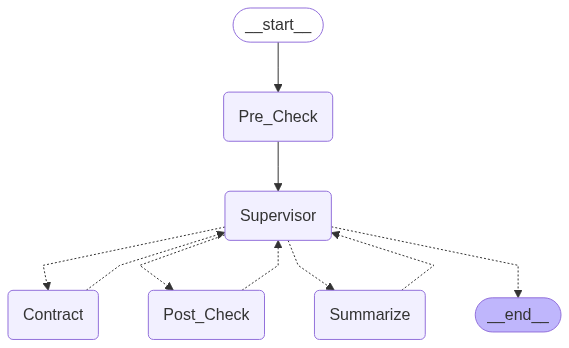

In [ ]:
# Visulalize the Graph

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [27]:
user_input= {
    "messages": HumanMessage(content="Task is initiated")
}

user_input

{'messages': HumanMessage(content='Task is initiated', additional_kwargs={}, response_metadata={})}

In [34]:
response= graph.invoke(user_input)

<- pre_check_agent ->
Pre_check Validation is Successfully completed and share result with 'Supervisor Agent'

<- supervisor ->
'Supervisor' is assigning task to Contract

<- contract_agent ->
Assign task of 'Contract Agent' is completed and also share result with 'Supervisor' 

<- supervisor ->
'Supervisor' is assigning task to Summarize

<- summarize_agent ->
Assign task of 'Summarize Agent' is completed and also share result with 'Supervisor'

<- supervisor ->
'Supervisor' is assigning task to Post_Check

<- post_check_agent ->
Assign task of 'Post Agent' is completed and also share result with Supervisor

<- supervisor ->
Well Done!!! All Tasks are completed


In [35]:
response

{'messages': [HumanMessage(content='Task is initiated', additional_kwargs={}, response_metadata={}, id='36db61d0-7bc2-4bcc-b5fb-6c5b57f09451'),
  SystemMessage(content="Your are a smart assistant. your task is to validate all parameters recveid from user's input before passing to Supervisor", additional_kwargs={}, response_metadata={}, id='641979ea-d8a1-4232-b241-705e663f4dca'),
  SystemMessage(content="You are a 'Supervisor Agent', Your taks is to assigning work to any member's ['Contract', 'Summarize', 'Post_Check'].", additional_kwargs={}, response_metadata={}),
  SystemMessage(content="You are a 'Contract Agent', Your taks is to perform only contract related work, and update to your Supervisor.", additional_kwargs={}, response_metadata={}),
  SystemMessage(content="You are a 'Supervisor Agent', Your taks is to assigning work to any member's ['Contract', 'Summarize', 'Post_Check'].", additional_kwargs={}, response_metadata={}),
  SystemMessage(content="\n    You are a 'Summarize Age

In [ ]:
response["messages"]

[HumanMessage(content='Task is initiated', additional_kwargs={}, response_metadata={}, id='36db61d0-7bc2-4bcc-b5fb-6c5b57f09451'),
 SystemMessage(content="Your are a smart assistant. your task is to validate all parameters recveid from user's input before passing to Supervisor", additional_kwargs={}, response_metadata={}, id='641979ea-d8a1-4232-b241-705e663f4dca'),
 SystemMessage(content="You are a 'Supervisor Agent', Your taks is to assigning work to any member's ['Contract', 'Summarize', 'Post_Check'].", additional_kwargs={}, response_metadata={}),
 SystemMessage(content="You are a 'Contract Agent', Your taks is to perform only contract related work, and update to your Supervisor.", additional_kwargs={}, response_metadata={}),
 SystemMessage(content="You are a 'Supervisor Agent', Your taks is to assigning work to any member's ['Contract', 'Summarize', 'Post_Check'].", additional_kwargs={}, response_metadata={}),
 SystemMessage(content="\n    You are a 'Summarize Agent', your taks is 

In [38]:
response["messages"][-1]

SystemMessage(content="You are a 'Supervisor Agent', Your taks is to assigning work to any member's ['Contract', 'Summarize', 'Post_Check'].", additional_kwargs={}, response_metadata={})

In [39]:
response["messages"][-1].content

"You are a 'Supervisor Agent', Your taks is to assigning work to any member's ['Contract', 'Summarize', 'Post_Check']."

In [40]:
print(response["messages"][-1].content)

You are a 'Supervisor Agent', Your taks is to assigning work to any member's ['Contract', 'Summarize', 'Post_Check'].


In [55]:
for key,value in response.items():
    if key == "messages":
        for content in value:
            print(content)

content='Task is initiated' additional_kwargs={} response_metadata={} id='36db61d0-7bc2-4bcc-b5fb-6c5b57f09451'
content="Your are a smart assistant. your task is to validate all parameters recveid from user's input before passing to Supervisor" additional_kwargs={} response_metadata={} id='641979ea-d8a1-4232-b241-705e663f4dca'
content="You are a 'Supervisor Agent', Your taks is to assigning work to any member's ['Contract', 'Summarize', 'Post_Check']." additional_kwargs={} response_metadata={}
content="You are a 'Contract Agent', Your taks is to perform only contract related work, and update to your Supervisor." additional_kwargs={} response_metadata={}
content="You are a 'Supervisor Agent', Your taks is to assigning work to any member's ['Contract', 'Summarize', 'Post_Check']." additional_kwargs={} response_metadata={}
content="\n    You are a 'Summarize Agent', your taks is to summarize the content of the input received from your Supervisor, do only Summarization and \n    update the